In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
import pprint


In [2]:

client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# Affiche un exemple de document
#doc = collection.find_one()
#pprint.pprint(doc)


📋 Activité mensuelle moyenne (proxy via reviews_per_month) :
shape: (60, 3)
┌─────────────────────────────────┬───────────────────────┬───────────────┐
│ property_type                   ┆ avg_reviews_per_month ┆ listing_count │
│ ---                             ┆ ---                   ┆ ---           │
│ str                             ┆ f64                   ┆ u32           │
╞═════════════════════════════════╪═══════════════════════╪═══════════════╡
│ Shared room in hostel           ┆ 4.428039              ┆ 51            │
│ Shared room in boutique hotel   ┆ 3.6                   ┆ 3             │
│ Private room in vacation home   ┆ 3.36                  ┆ 2             │
│ Room in hostel                  ┆ 3.096667              ┆ 6             │
│ Religious building              ┆ 2.92                  ┆ 1             │
│ …                               ┆ …                     ┆ …             │
│ Entire villa                    ┆ 0.266667              ┆ 9             │
│ Cave      

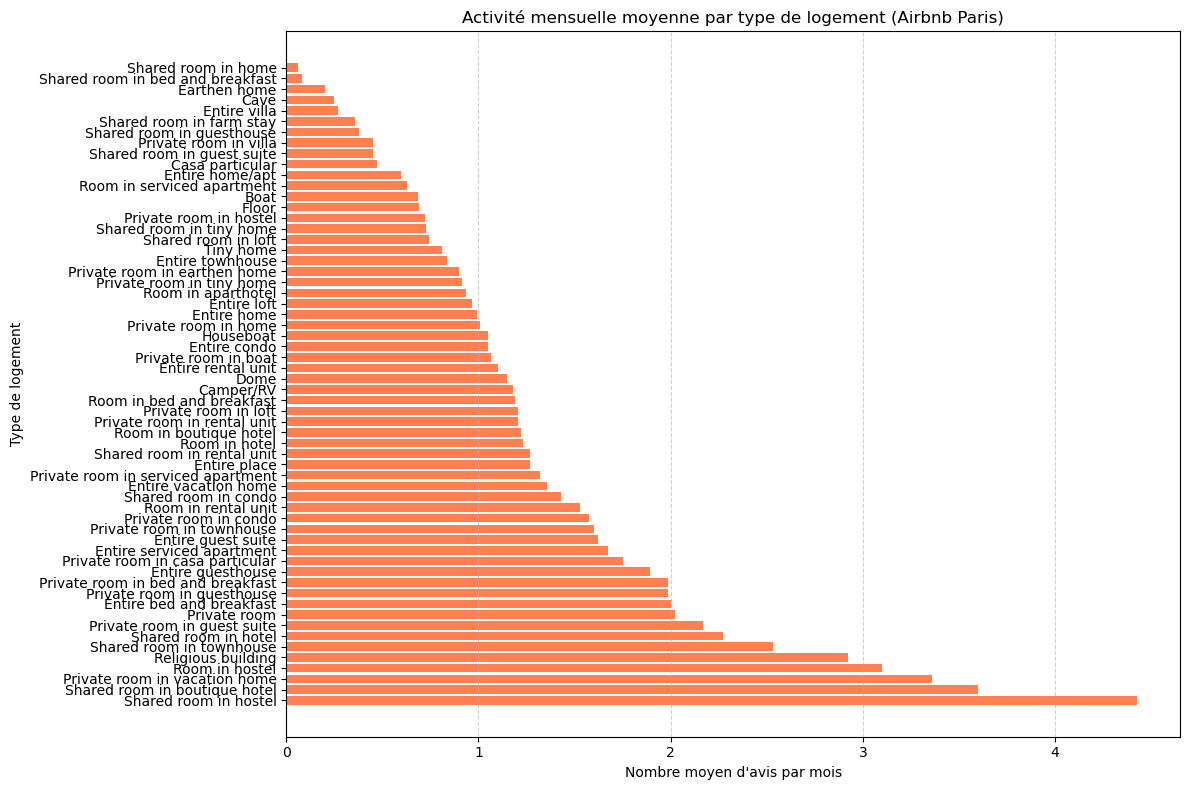

In [7]:
# 1️⃣ Connexion à MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# 2️⃣ Extraction des données utiles
cursor = collection.find(
    {
        "property_type": {"$exists": True},
        "reviews_per_month": {"$exists": True, "$ne": None}
    },
    {
        "_id": 0,
        "property_type": 1,
        "reviews_per_month": 1
    }
)

rows = list(cursor)
if not rows:
    raise ValueError("❌ Aucune donnée valide trouvée.")

# 3️⃣ Chargement dans Polars
df = pl.DataFrame(rows)

# 4️⃣ Agrégation (API Polars correcte)
agg = (
    df
    .group_by("property_type")   # ✅ group_by et non groupby
    .agg([
        pl.mean("reviews_per_month").alias("avg_reviews_per_month"),
        pl.len().alias("listing_count")
    ])
    .sort("avg_reviews_per_month", descending=True)
)

# 5️⃣ Résultat
print("📋 Activité mensuelle moyenne (proxy via reviews_per_month) :")
print(agg)

# 6️⃣ Visualisation 📊
pdf = agg.to_pandas()

plt.figure(figsize=(12, 8))
plt.barh(pdf["property_type"], pdf["avg_reviews_per_month"], color="coral")
plt.xlabel("Nombre moyen d'avis par mois")
plt.ylabel("Type de logement")
plt.title("Activité mensuelle moyenne par type de logement (Airbnb Paris)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


📊 Médiane du nombre d’avis : 3.0


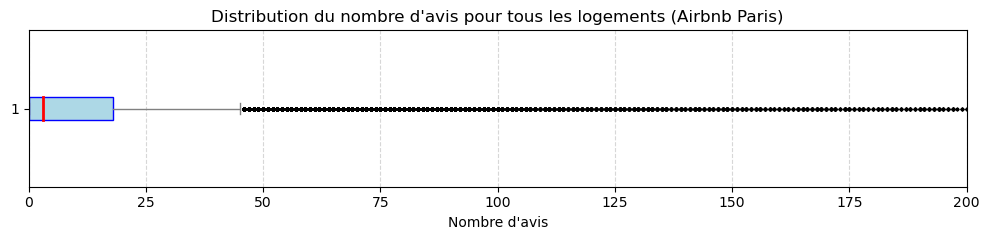

In [19]:
# 📦 Imports
#  from pymongo import MongoClient
#  import polars as pl
#  import matplotlib.pyplot as plt

# 1️⃣ Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# 2️⃣ Extraction des données : number_of_reviews
cursor = collection.find(
    {
        "number_of_reviews": {"$exists": True, "$ne": None}
    },
    {
        "_id": 0,
        "number_of_reviews": 1
    }
)

rows = list(cursor)
if not rows:
    raise ValueError("❌ Aucune donnée avec 'number_of_reviews' trouvée.")

# 3️⃣ Chargement dans Polars
df = pl.DataFrame(rows)

# 4️⃣ Médiane
median_reviews = df.select(pl.median("number_of_reviews")).item()
print(f"📊 Médiane du nombre d’avis : {median_reviews}")

# 5️⃣ Boxplot avec limitation de l’axe X
plt.figure(figsize=(10, 2.5))  # petite hauteur pour visuel "compact"
plt.boxplot(df["number_of_reviews"], vert=False,
            patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="gray"),
            capprops=dict(color="gray"),
            flierprops=dict(marker=".", markersize=3, color="gray", linestyle="none"))

plt.title("Distribution du nombre d'avis pour tous les logements (Airbnb Paris)")
plt.xlabel("Nombre d'avis")
plt.xlim(0, 200)  # ✅ Limite volontaire pour améliorer la lisibilité
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


📋 Médiane du nombre d’avis par catégorie d’hôte :
shape: (2, 3)
┌───────────────────┬────────────────┬───────┐
│ host_is_superhost ┆ median_reviews ┆ count │
│ ---               ┆ ---            ┆ ---   │
│ bool              ┆ f64            ┆ u32   │
╞═══════════════════╪════════════════╪═══════╡
│ false             ┆ 2.0            ┆ 81035 │
│ true              ┆ 24.0           ┆ 14776 │
└───────────────────┴────────────────┴───────┘


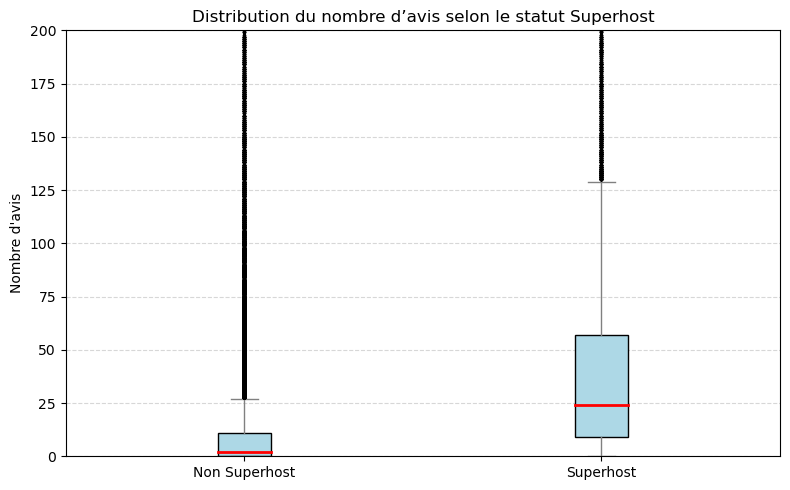

In [21]:
# 2️⃣ Extraction des données utiles
cursor = collection.find(
    {
        "host_is_superhost": {"$exists": True},
        "number_of_reviews": {"$exists": True, "$ne": None}
    },
    {
        "_id": 0,
        "host_is_superhost": 1,
        "number_of_reviews": 1
    }
)

rows = list(cursor)
if not rows:
    raise ValueError("❌ Aucune donnée trouvée avec 'host_is_superhost' et 'number_of_reviews'.")

# 3️⃣ Chargement dans Polars
df = pl.DataFrame(rows)

# 4️⃣ Calcul des médianes par groupe
grouped = (
    df
    .group_by("host_is_superhost")
    .agg([
        pl.median("number_of_reviews").alias("median_reviews"),
        pl.len().alias("count")
    ])
    .sort("host_is_superhost")
)

print("📋 Médiane du nombre d’avis par catégorie d’hôte :")
print(grouped)

# 5️⃣ Préparation pour boxplot : séparer les deux groupes
group_true = df.filter(pl.col("host_is_superhost") == True)["number_of_reviews"]
group_false = df.filter(pl.col("host_is_superhost") == False)["number_of_reviews"]

# 6️⃣ Boxplot par catégorie
plt.figure(figsize=(8, 5))
plt.boxplot([group_false, group_true],
            labels=["Non Superhost", "Superhost"],
            patch_artist=True,
            boxprops=dict(facecolor="lightblue"),
            medianprops=dict(color="red", linewidth=2),
            flierprops=dict(marker=".", markersize=3, color="gray", linestyle="none"),
            whiskerprops=dict(color="gray"),
            capprops=dict(color="gray"))

plt.title("Distribution du nombre d’avis selon le statut Superhost")
plt.ylabel("Nombre d'avis")
plt.ylim(0, 200)  # ✅ Pour limiter les effets d’écrasement
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


📋 Nombre de logements par quartier (Top 10) :
shape: (10, 2)
┌────────────────────────┬────────────────┐
│ neighbourhood_cleansed ┆ logement_count │
│ ---                    ┆ ---            │
│ str                    ┆ u32            │
╞════════════════════════╪════════════════╡
│ Buttes-Montmartre      ┆ 10555          │
│ Popincourt             ┆ 8430           │
│ Vaugirard              ┆ 7802           │
│ Batignolles-Monceau    ┆ 6857           │
│ Entrepôt               ┆ 6558           │
│ Passy                  ┆ 6407           │
│ Buttes-Chaumont        ┆ 5465           │
│ Ménilmontant           ┆ 5271           │
│ Opéra                  ┆ 4570           │
│ Reuilly                ┆ 4003           │
└────────────────────────┴────────────────┘


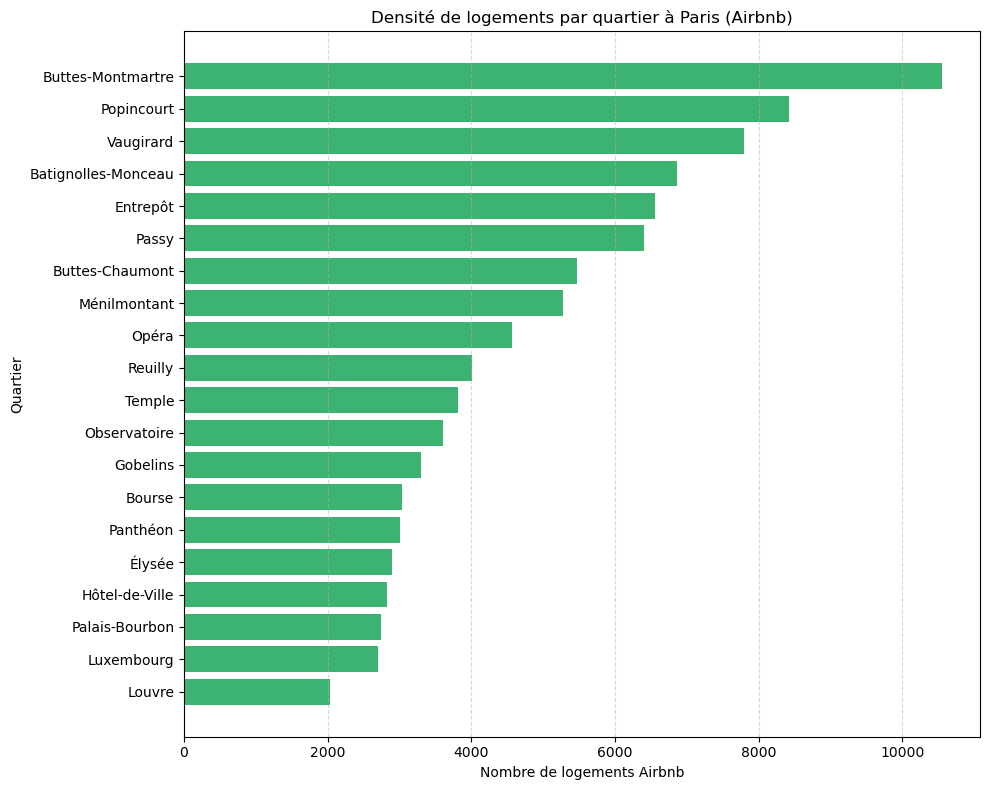

In [23]:
# 📦 Imports
from pymongo import MongoClient
import polars as pl
import matplotlib.pyplot as plt

# 1️⃣ Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# 2️⃣ Extraction : quartiers présents
cursor = collection.find(
    {
        "neighbourhood_cleansed": {"$exists": True, "$ne": None}
    },
    {
        "_id": 0,
        "neighbourhood_cleansed": 1
    }
)

rows = list(cursor)
if not rows:
    raise ValueError("❌ Aucune donnée avec 'neighbourhood_cleansed' trouvée.")

# 3️⃣ Chargement dans Polars
df = pl.DataFrame(rows)

# 4️⃣ Comptage par quartier
agg = (
    df
    .group_by("neighbourhood_cleansed")
    .agg(pl.len().alias("logement_count"))
    .sort("logement_count", descending=True)
)

print("📋 Nombre de logements par quartier (Top 10) :")
print(agg.head(10))

# 5️⃣ Visualisation 📊
pdf = agg.to_pandas()

plt.figure(figsize=(10, 8))
plt.barh(pdf["neighbourhood_cleansed"], pdf["logement_count"], color="mediumseagreen")
plt.xlabel("Nombre de logements Airbnb")
plt.ylabel("Quartier")
plt.title("Densité de logements par quartier à Paris (Airbnb)")
plt.gca().invert_yaxis()  # Quartiers les plus denses en haut
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


📋 Quartiers avec le plus fort taux estimé de réservation (via reviews_per_month) :
shape: (10, 3)
┌────────────────────────┬───────────────────────┬───────────────┐
│ neighbourhood_cleansed ┆ avg_reviews_per_month ┆ listing_count │
│ ---                    ┆ ---                   ┆ ---           │
│ str                    ┆ f64                   ┆ u32           │
╞════════════════════════╪═══════════════════════╪═══════════════╡
│ Bourse                 ┆ 1.577269              ┆ 2296          │
│ Louvre                 ┆ 1.384321              ┆ 1465          │
│ Élysée                 ┆ 1.320271              ┆ 1845          │
│ Temple                 ┆ 1.256014              ┆ 2918          │
│ Hôtel-de-Ville         ┆ 1.243083              ┆ 2079          │
│ Palais-Bourbon         ┆ 1.208487              ┆ 1725          │
│ Vaugirard              ┆ 1.197236              ┆ 4967          │
│ Opéra                  ┆ 1.184905              ┆ 3119          │
│ Entrepôt               ┆ 1.18

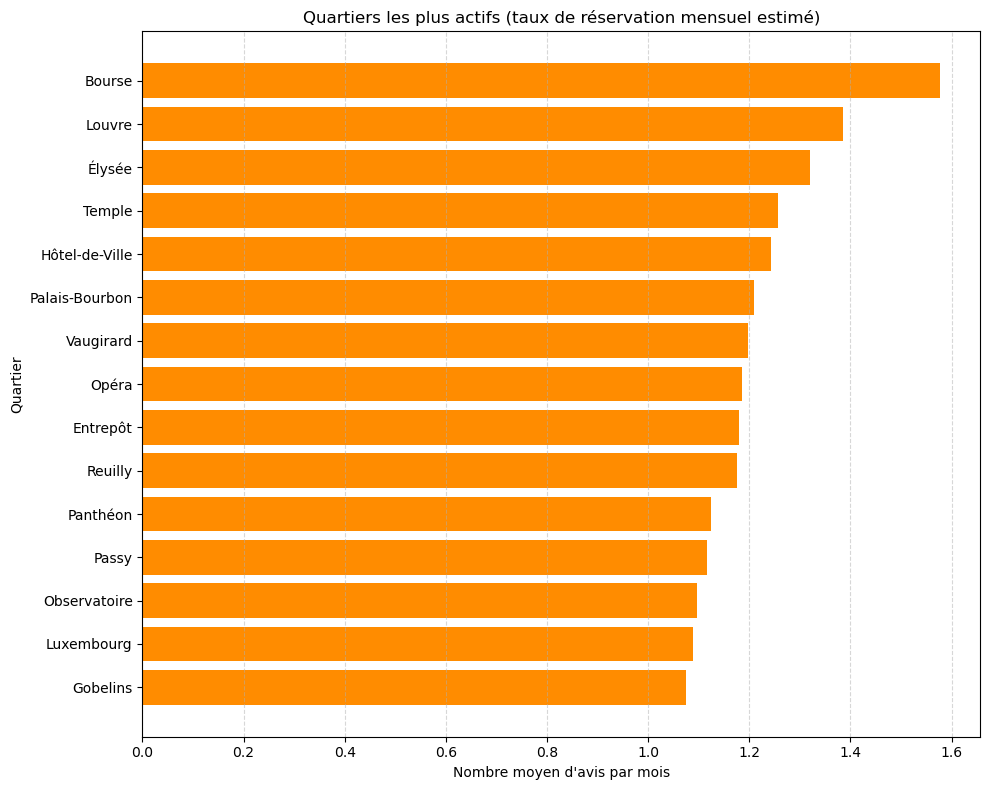

In [24]:
# 📦 Imports
from pymongo import MongoClient
import polars as pl
import matplotlib.pyplot as plt

# 1️⃣ Connexion MongoDB
client = MongoClient("mongodb://localhost:27017")
db = client["airbnb"]
collection = db["logements-paris"]

# 2️⃣ Extraction des champs nécessaires
cursor = collection.find(
    {
        "reviews_per_month": {"$exists": True, "$ne": None},
        "neighbourhood_cleansed": {"$exists": True, "$ne": None}
    },
    {
        "_id": 0,
        "reviews_per_month": 1,
        "neighbourhood_cleansed": 1
    }
)

rows = list(cursor)
if not rows:
    raise ValueError("❌ Aucune donnée avec 'reviews_per_month' et 'neighbourhood_cleansed' trouvée.")

# 3️⃣ Chargement dans Polars
df = pl.DataFrame(rows)

# 4️⃣ Calcul du taux estimé par quartier
agg = (
    df
    .group_by("neighbourhood_cleansed")
    .agg([
        pl.mean("reviews_per_month").alias("avg_reviews_per_month"),
        pl.len().alias("listing_count")
    ])
    .sort("avg_reviews_per_month", descending=True)
)

# 5️⃣ Affichage console — top 10
print("📋 Quartiers avec le plus fort taux estimé de réservation (via reviews_per_month) :")
print(agg.head(10))

# 6️⃣ Visualisation — top 15 quartiers
pdf = agg.head(15).to_pandas()

plt.figure(figsize=(10, 8))
plt.barh(pdf["neighbourhood_cleansed"], pdf["avg_reviews_per_month"], color="darkorange")
plt.xlabel("Nombre moyen d'avis par mois")
plt.ylabel("Quartier")
plt.title("Quartiers les plus actifs (taux de réservation mensuel estimé)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
